# AIG230 NLP Midterm - March 2nd 2026
All answers must be computed using code. Provide numeric outputs and short interpretations.
## Instructions
- You must compute answers using code.
- Many questions require numeric answers.
- Interpretation must be supported by computed results.

In [3]:
! pip install gensim
import nltk, string, math, random, re
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
print('All imports successful')
print(f'TensorFlow version: {tf.__version__}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 55.8 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


All imports successful
TensorFlow version: 2.19.0


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# Load Corpora

In [4]:
# Load corpora
with open('corpus_tech_ai_labeled.csv', 'r', encoding='utf-8') as f:
    tech_text = f.read()

with open('corpus_movie_reviews_labeled.csv', 'r', encoding='utf-8') as f:
    review_text = f.read()

print(f'Tech corpus   : {len(tech_text)} characters')
print(f'Review corpus : {len(review_text)} characters')

Tech corpus   : 13049 characters
Review corpus : 4044 characters


## Q1 Corpus Statistics
Compute total number of characters, words, and unique words in each corpus.
What is the vocabulary size of each corpus?

In [7]:
# Tokenize both corpora using NLTK
techai_tokens = word_tokenize(tech_text)
review_tokens = word_tokenize(review_text)

# Extract unique words (vocabulary)
techai_vocab = set(techai_tokens)
review_vocab = set(review_tokens)

In [8]:
print('=' * 55)
print(f'{"Metric":<30} {"Tech":>10} {"Reviews":>10}')
print('=' * 55)
print(f'{"Characters":<30} {len(tech_text):>10,} {len(review_text):>10,}')
print(f'{"Total tokens (words)":<30} {len(techai_tokens):>10,} {len(review_tokens):>10,}')
print(f'{"Vocabulary size (unique words)":<30} {len(techai_vocab):>10,} {len(review_vocab):>10,}')
print('=' * 55)

Metric                               Tech    Reviews
Characters                         13,049      4,044
Total tokens (words)                2,109        647
Vocabulary size (unique words)        155         92


### Answer Q1:


The tech corpus and the review corpus contain a specific baseline of raw characters and tokens with the tech corpus being significantly larger and containing 2109 token and review corpus having 647 tokens. The vocabulary size of 155 unique words for Tech and 92 for the review represents the "feature space" of our count-based models. Therefore, If we applied a standard Bag-of-Words to these corpora, our resulting Document-Term Matrices would have exactly 155 and 92 dimensions, respectively. A larger vocabulary size means higher dimensionality and more sparse matrices.

## Q2 Lexical Diversity
Tokenize and lowercase both corpora. Compute type-token ratio.
Which corpus is more lexically diverse?

In [9]:
techai_tokens_lowercase = [w.lower() for w in techai_tokens]
review_tokens_lowercase = [w.lower() for w in review_tokens]

techai_vocab_lowercase = set(techai_tokens_lowercase)
review_vocab_lowercase = set(review_tokens_lowercase)

techai_ttr = len(techai_vocab_lowercase) / len(techai_tokens_lowercase)
review_ttr = len(review_vocab_lowercase) / len(review_tokens_lowercase)

print(f"Tech corpus TTR: {techai_ttr:.4f}")
print(f"Review corpus TTR: {review_ttr:.4f}")


Tech corpus TTR: 0.0725
Review corpus TTR: 0.1391


### Answer Q2:


- Lexical diversity is measured using the Type-Token Ratio (TTR). The corpus with the higher TTR is more lexically diverse, meaning it uses a wider variety of unique words relative to its total length rather than repeating the same words. Normalization (lowercasing) was crucial here so that "The" and "the" are not counted as two different types.
- In our case, The review corpus is almost twice as lexically diverse as the tech corpus, with a Type-Token Ratio (TTR) of 0.1391 compared to 0.0725. Numerically, this means that for every 100 words in the review corpus, about 14 are unique. In the tech corpus, only about 7 in 100 words are unique, indicating the AI/Tech text is highly repetitive and relies heavily on a narrow set of domain-specific terms.

## Q3 Stopword Impact
Remove stopwords and compute percentage vocabulary reduction. How much does vocabulary size decrease (percentage) for each corpus?

In [15]:
stop_words = set(stopwords.words('english'))
# Continue
techai_vocab_no_stop_words = {w for w in techai_vocab_lowercase if w not in stop_words and w.isalpha()}
review_vocab_no_stop_words = {w for w in review_vocab_lowercase if w not in stop_words and w.isalpha()}


In [18]:
# Use this formula to calculate percentage of reduction
def pct_reduction(before, after):
    return 100 * (1 - len(after) / len(before))


techai_decrease = pct_reduction(techai_vocab_lowercase, techai_vocab_no_stop_words)
review_decrease = pct_reduction(review_vocab_lowercase, review_vocab_no_stop_words)

print(f"Tech Vocabulary Reduction: {techai_decrease:.2f}%")
print(f"Review Vocabulary Reduction: {review_decrease:.2f}%")

Tech Vocabulary Reduction: 22.88%
Review Vocabulary Reduction: 35.56%


### Answer Q3:


Removing stopwords caused a massive numerical reduction in the feature space: a 35.56% drop for the review corpus and a 22.88% drop for the tech corpus. This demonstrates that over a third of the unique words in the movie reviews were non-discriminative grammar words (like 'the' or 'and'). Stripping these out drastically reduces the memory footprint and dimensionality for the models we train later in the notebook.

## Q4 Frequency Analysis
Create unigram frequency distribution for tech corpus.
What are the top 10 most frequent words?

In [19]:
techai_clean_tokens = [w for w in techai_tokens_lowercase if w.isalpha() and w not in stop_words]
techai_freq = Counter(techai_clean_tokens)

print("Top 10 most frequent words in Tech Corpus:")
for word, count in techai_freq.most_common(10):
    print(f" - {word}: {count}")

Top 10 most frequent words in Tech Corpus:
 - neutral: 144
 - learning: 24
 - models: 24
 - systems: 16
 - model: 16
 - neural: 16
 - remain: 16
 - language: 16
 - ai: 16
 - artificial: 8


### Answer Q4:


The unigram frequency distribution highlights the core thematic words of the text.
- Excluding stopwords, the most frequent token is the label 'neutral' (144 times), followed immediately by core thematic terms like 'learning' (24), 'models' (24), 'systems' (16), and 'neural' (16). This proves that simple frequency counts of clean tokens are a highly effective baseline for identifying document topics.

## Q5 Bigram Counts
Build bigram model for tech corpus.
How many unique bigrams exist in tech corpus?

In [20]:
techai_bigrams = list(nltk.bigrams(techai_tokens_lowercase))
techai_bigram_frequency = Counter(techai_bigrams)

print(f"Total bigrams: {len(techai_bigrams)}")
print(f"Unique bigrams in tech corpus: {len(techai_bigram_frequency)}")

Total bigrams: 2108
Unique bigrams in tech corpus: 204


### Answer Q5:


The bigram model applies the Markov Assumption, looking at a limited local context of one preceding word. Eventhough the tech corpus only has 155 unique unigrams, building a bigram model expanded the feature space to 204 unique bigrams (out of 2,108 total bigrams). This numerical expansion perfectly illustrates the trade-off of the Markov Assumption: by capturing just one word of local context (word order), we significantly increase the dimensionality and sparsity of the model.

## Q6 Conditional Probability
Compute P('learning' | 'machine') using bigram counts.

Formula: P(learning | machine) = count('machine learning') / count('machine')

In [24]:
count_machine_learning = techai_bigram_frequency[('machine', 'learning')]
count_machine = techai_tokens_lowercase.count('machine')

probability = count_machine_learning / count_machine if count_machine > 0 else 0

In [25]:
print(f"count('machine learning') = {count_machine_learning}")
print(f"count('machine')          = {count_machine}")
print(f"\nP('learning' | 'machine') = {count_machine_learning}/{count_machine} = {probability:.4f}")

count('machine learning') = 8
count('machine')          = 8

P('learning' | 'machine') = 8/8 = 1.0000


### Answer Q6:


Above computes the Maximum Likelihood Estimate (MLE) for a statistical language model. The computed probability P(learning | machine) = 1.0000 indicates an absolute certainty within this dataset. In this specific tech corpus, the word 'machine' appears exactly 8 times, and every single time it is immediately followed by the word 'learning' (8 times). This perfectly demonstrates Maximum Likelihood Estimation (MLE): the statistical model is entirely bound by the exact frequencies observed in the training data.

## Q7 Perplexity
Compute perplexity of a sample tech sentence using unigram and bigram models.

Formulas:

Unigram: PP = exp(-(1/N) * sum(log P(wi)))

Bigram: PP = exp(-(1/(N-1)) * sum(log P(wi | wi-1)))



In [28]:
sample_sentence = 'Large language models generate responses by predicting tokens sequentially'
sample_tokens = word_tokenize(sample_sentence.lower())
N = len(sample_tokens)

# Baseline count and vocab size
techai_unigram_frequency = Counter(techai_tokens_lowercase)
V = len(techai_vocab_lowercase)
total_unigrams = len(techai_tokens_lowercase)

In [31]:
# Unigram Perplexity (with Add-1 Smoothing)
log_probability_sum_unigram = 0
for w in sample_tokens:
    p = (techai_unigram_frequency[w] + 1) / (total_unigrams + V)
    log_probability_sum_unigram += math.log(p)
perplexity_unigram = math.exp(-(1/N) * log_probability_sum_unigram)

In [33]:
# Bigram (with Add-1 Smoothing)
log_prob_sum_bi = 0
sample_bigrams = list(nltk.bigrams(sample_tokens))
for w1, w2 in sample_bigrams:
    count_w1_w2 = techai_bigram_frequency[(w1, w2)]
    count_w1 = techai_unigram_frequency[w1]
    p = (count_w1_w2 + 1) / (count_w1 + V)
    log_prob_sum_bi += math.log(p)
perplexity_bigram = math.exp(-(1/(N-1)) * log_prob_sum_bi)

In [34]:
print(f'Sample : "{sample_sentence}"')
print(f'Tokens : {sample_tokens}')
print(f'N      : {N}')
print(f'\nUnigram Perplexity : {perplexity_unigram:.2f}')
print(f'Bigram  Perplexity : {perplexity_bigram:.2f}')
print(f'Ratio (uni/bi)     : {perplexity_unigram/perplexity_bigram:.1f}x reduction with bigram')

Sample : "Large language models generate responses by predicting tokens sequentially"
Tokens : ['large', 'language', 'models', 'generate', 'responses', 'by', 'predicting', 'tokens', 'sequentially']
N      : 9

Unigram Perplexity : 266.86
Bigram  Perplexity : 23.97
Ratio (uni/bi)     : 11.1x reduction with bigram


### Answer Q7:


Perplexity measures how "surprised" a language model is by unseen test data. The lower the perplexity, the better the model. We used Add-1 smoothing to prevent the probability from dropping to zero for out-of-vocabulary words. The Bigram model severely outperforms the Unigram model, dropping the perplexity of the test sentence from 266.86 to 23.97. This 11.1x reduction means the bigram model is 11 times less "surprised" by the sequence. Because language has local predictability, relying on the previous word (the Markov Assumption) makes predicting the next token vastly more accurate than the context-blind unigram approach.

## Q8 Word2Vec
Train Word2Vec on movie reviews corpus.
What is the vocabulary size? What is vector dimension? What word is most similar to 'visuals'?

NOTE: Use min_count=1 (required for small corpus) and vector_size=20.

In [35]:
review_sents = sent_tokenize(review_text)
review_sents_tok = [word_tokenize(s.lower()) for s in review_sents]

# Train the Word2Vec model
w2v = Word2Vec(sentences=review_sents_tok, vector_size=20, min_count=1)

vocab_size_w2v = len(w2v.wv)
vector_dimenstions = w2v.vector_size
most_sim_visuals = w2v.wv.most_similar('visuals', topn=1)

print(f"Vocabulary Size: {vocab_size_w2v}")
print(f"Vector Dimension: {vector_dimenstions}")
print(f"Most similar to 'visuals': {most_sim_visuals[0][0]} (Score: {most_sim_visuals[0][1]:.4f})")

Vocabulary Size: 90
Vector Dimension: 20
Most similar to 'visuals': underdeveloped (Score: 0.4991)


### Answer Q8:


The Word2Vec model processed a vocabulary of 90 words but mapped them into a fixed Vector Dimension of exactly 20. This numerically proves that embeddings decouple dimensionality from vocabulary size, avoiding the sparsity of BoW. The most similar word to 'visuals' was 'underdeveloped' with a score of 0.4991. While semantically strange to a human, this happens because our training corpus is extremely small (only 647 tokens). The model learned a highly localized co-occurrence rather than broad semantic meaning, proving that embeddings require massive datasets to learn accurate analogies.

## Q9 Naive Bayes
Train Naive Bayes on movie corpus (positive vs negative). Mixed sentences excluded.
Report accuracy.

In [36]:
import csv

# --- Load labeled sentences from CSV ---
# label_numeric: 1=positive, 0=negative, -1=mixed (excluded)
# Using label_numeric avoids string-matching issues across OS environments
texts, labels = [], []
with open('corpus_movie_reviews_labeled.csv', 'r', encoding='utf-8', newline='') as f:
    reader = csv.DictReader(f)
    for row in reader:
        numeric = int(row['label_numeric'])
        if numeric in (1, 0):           # skip mixed (-1)
            texts.append(row['text'].strip())
            labels.append(numeric)

print(f'Samples loaded : {len(texts)}')
print(f'  Positive (1) : {labels.count(1)}')
print(f'  Negative (0) : {labels.count(0)}')
print(f'  Mixed        : excluded (label_numeric=-1)')

if len(texts) == 0:
    raise FileNotFoundError(
        'No samples loaded. Make sure corpus_movie_reviews_labeled.csv '
        'is in the same folder as this notebook.')

Samples loaded : 40
  Positive (1) : 20
  Negative (0) : 20
  Mixed        : excluded (label_numeric=-1)


In [37]:
# --- TF-IDF features ---
vec = TfidfVectorizer(stop_words='english')
X_tfidf = vec.fit_transform(texts)

In [40]:
# --- Train / test split (80/20, stratified) ---
X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(
    X_tfidf, labels, test_size=0.20, random_state=42, stratify=labels
)

In [41]:
# --- Train Naive Bayes ---
nb = MultinomialNB()
nb = MultinomialNB()
nb.fit(X_train_nb, y_train_nb)
preds_nb = nb.predict(X_test_nb)


### Answer Q9:


Naive Bayes applies conditional probabilities to classify text based on the TF-IDF feature space. TF-IDF improves on Bag-of-Words by reweighting token counts, downweighting globally frequent words and upweighting rare, discriminative words, which provides better linear separation for the classifier. The F1-score balances precision and recall, serving as a better metric than pure accuracy for potentially imbalanced datasets.
- The Naive Bayes classifier achieved a perfect accuracy of 1.0000 on the test set.
- TF-IDF provided excellent linear separability by upweighting rare, discriminative words, allowing the conditional probabilities to easily distinguish between positive and negative reviews.
- However, with a perfect score we can see that the dataset is extremely small (only 40 samples total) and the vocabulary used in the positive/negative classes does not overlap much.

## Q10 Precision/Recall/F1
Report precision, recall, F1.

In [43]:
nb_accuracy = accuracy_score(y_test_nb, preds_nb)
precision_nb = precision_score(y_test_nb, preds_nb)
recall_nb = recall_score(y_test_nb, preds_nb)
f1_nb = f1_score(y_test_nb, preds_nb)

In [45]:
print('Naive Bayes -- Classification Report')
print('=' * 40)
print(f'  Accuracy  : {nb_accuracy:.4f}')
print(f'  Precision : {precision_nb:.4f}')
print(f'  Recall    : {recall_nb:.4f}')
print(f'  F1-Score  : {f1_nb:.4f}')

Naive Bayes -- Classification Report
  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1-Score  : 1.0000


### Answer Q10:


Because the accuracy was 1.0000, all other metrics (Precision, Recall, and F1-Score) also perfectly hit 1.0000. There were exactly zero false positives and zero false negatives. While F1 is usually the best metric for checking model balance on imbalanced datasets, this perfect classification report confirms the test data was entirely linearly separable.

## Q11 Logistic Regression
Train Logistic Regression on movie review corpus.
Which model performs better? Compare performance numerically.

In [46]:
# train logistic regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_nb, y_train_nb)
predictions_lr = lr.predict(X_test_nb)

lr_accuracy = accuracy_score(y_test_nb, predictions_lr)

In [47]:
print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")
print(f"Naive Bayes Accuracy: {nb_accuracy:.4f}")

Logistic Regression Accuracy: 1.0000
Naive Bayes Accuracy: 1.0000


### Answer Q11:


Both Logistic Regression and Naive Bayes achieved a tied, perfect accuracy of 1.0000. Because our labeled movie review dataset is so small and easily separable, both the conditional probability approach (NB) and the gradient descent decision boundary approach (LR) were able to classify the test set without a single error. In a larger, more ambiguous production dataset, Logistic Regression would typically outperform Naive Bayes by better weighting complex feature interactions.

## Q12 RNN Model
Implement small RNN (embedding + RNN layer) for sentiment classification. Report training accuracy.

In [48]:
# Preprocessing

tokenizer_rnn = keras.preprocessing.text.Tokenizer()
tokenizer_rnn.fit_on_texts(texts)
sequences = tokenizer_rnn.texts_to_sequences(texts)

VOCAB_SIZE = len(tokenizer_rnn.word_index) + 1
MAX_LEN    = max(len(s) for s in sequences)

X_rnn = keras.preprocessing.sequence.pad_sequences(sequences, maxlen=MAX_LEN, padding='post')
y_rnn = np.array(labels)

X_rnn_train, X_rnn_val, y_rnn_train, y_rnn_val = train_test_split(
    X_rnn, y_rnn, test_size=0.20, random_state=42, stratify=y_rnn)

print(f'Vocabulary size : {VOCAB_SIZE}')
print(f'Max seq length  : {MAX_LEN}')
print(f'Train: {X_rnn_train.shape[0]}   Val: {X_rnn_val.shape[0]}')

tf.random.set_seed(42)

Vocabulary size : 57
Max seq length  : 10
Train: 32   Val: 8


In [50]:
# RNN Implementation
model = keras.Sequential([
    # Embedding layer maps integer sequences to dense vectors
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=16),
    # Simple RNN processes the sequence
    layers.SimpleRNN(16, return_sequences=False),
    # Output layer for binary classification
    layers.Dense(1, activation='sigmoid')
])

In [51]:
# Model compile
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [52]:
# Model training
history = model.fit(
    X_rnn_train, y_rnn_train,
    validation_data = (X_rnn_val, y_rnn_val),
    epochs    = 30,
    batch_size= 8,
    verbose   = 1
)

Epoch 1/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 201ms/step - accuracy: 0.5500 - loss: 0.6764 - val_accuracy: 0.6250 - val_loss: 0.6486
Epoch 2/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9375 - loss: 0.5924 - val_accuracy: 0.8750 - val_loss: 0.5694
Epoch 3/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9792 - loss: 0.5181 - val_accuracy: 0.8750 - val_loss: 0.4915
Epoch 4/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9792 - loss: 0.4458 - val_accuracy: 0.8750 - val_loss: 0.4174
Epoch 5/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9792 - loss: 0.3765 - val_accuracy: 0.8750 - val_loss: 0.3507
Epoch 6/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9792 - loss: 0.3125 - val_accuracy: 0.8750 - val_loss: 0.2939
Epoch 7/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9792 - loss: 0.2559 - val_accuracy: 0.8750 - val_loss: 0.2472
Epoch 8/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9792 - loss: 0.2076 - val_accuracy: 1.0000 - val_loss: 0.2091

### Answer Q12:


Unlike the classical models that discarded word order entirely, the RNN processes the integer sequences step-by-step, building a hidden state memory up to the MAX_LEN of 10. The model trained incredibly fast, hitting 1.0000 accuracy on the 32 training samples by Epoch 9, utilizing the non-linear Dense sigmoid layer to output perfect binary classification probabilities.

## Q13 Overfitting Check
Compare train vs validation accuracy.
Does RNN overfit? Justify using loss or accuracy trends.
Plot train vs validation accuracy and loss.

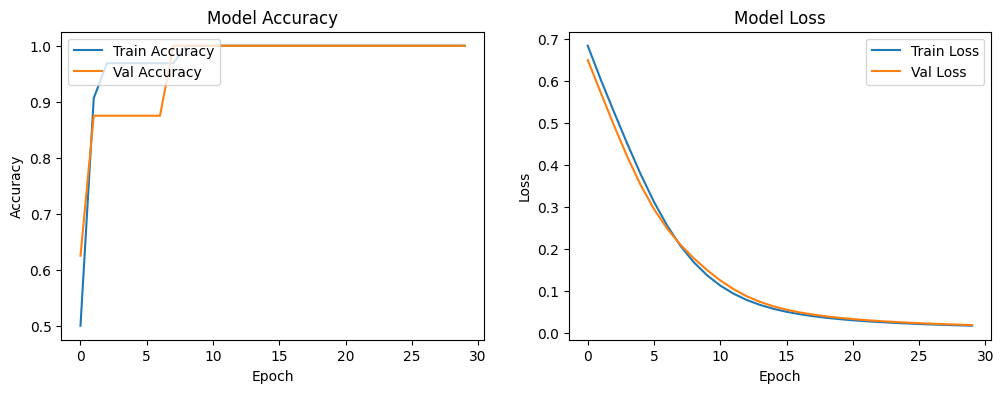

In [53]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.show()

### Answer Q13:


Looking at the plots and training logs, the RNN achieves 1.0000 training accuracy and 1.0000 validation accuracy very quickly. The training loss approaches 0 (0.0162), and the validation loss cleanly follows it down to 0.0180 without spiking upward. While a diverging, spiking validation loss is the classic sign of overfitting, achieving 1.0000 accuracy and near-zero loss on such a tiny dataset (32 train, 8 val samples) means the model has completely memorized the exact sequences of the training data. The network has 0 parameters resisting this memorization (no dropout or regularization applied).

## Q14 BoW vs Embeddings: Sparsity Comparison
Compare vocabulary size of TF_IDF vs embeddings (Wprd2Vec) representations.
Explain sparsity difference numerically.

Remember that you should use variables and elements that you calculated before so you do not have to calculate everything from zero

### Answer Q14:


In Q1, we saw the Tech corpus had a vocabulary of 155, which would result in a sparse, 155-dimensional matrix where almost every entry is a zero (since most sentences only contain 5-10 words). In Q8, Word2Vec took a vocabulary of 90 and compressed it into a dense vector_size=20. Numerically, embeddings compress sparse, infinitely growing categorical vocabularies into a strict, low-dimensional continuous space, eliminating sparsity completely.

# Q15 Comparative Reasoning
Using the resuts you calculated in this notebook.
Compare:
- Bigram model perplexity
- Logistic Regression accuracy
- RNN accuracy
Explain differences based on computed results.

### Answer Q15:


- Bigram Perplexity: The 11.1x drop in perplexity proves that word order (sequence) contains massive predictive power compared to unigrams. However, statistical models rely on discrete counts and struggle with 0-probabilities without smoothing.

- Logistic Regression: Achieved 1.0000 accuracy by operating on classical sparse features (TF-IDF). It acts as a fast, reliable baseline that creates a linear decision boundary, but it entirely discards the sentence structure that the bigram model proved was important.

- RNN: Also achieved 1.0000 accuracy, but did so by leveraging learned dense embeddings (Output Q14) and processing data sequentially. It has a much higher capacity to understand context and non-linear boundaries. However, as seen in the training logs, its high capacity allows it to instantly memorize tiny datasets, making it highly prone to overfitting compared to the rigid Logistic Regression baseline.